In [1]:
import sys
sys.path.insert(1, '/work1/okoro/type3detectosra/')

import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os

fname = "/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh"

# Frequency arrays
f1 = 800.0 - np.array(range(256))*400./256.
f2 = 400.0 - np.array(range(256))*200./255.
f3 = 170.0 - np.array(range(256))*70./256.
f4 = 100.0 - np.array(range(256))*60./255.
f_fits = np.concatenate((f1,f2,f3,f4))
Frequency = f_fits[0:1024]

In [2]:
# Get file size
file_stats = os.stat(fname)
a1 = int(file_stats.st_size / 1040 + 0.5)
print(f"Total time steps: {a1}")

Total time steps: 594606


In [3]:
# For display, target a reasonable number of columns (e.g., 2000,20000,50000)
target_display_columns = 59400
display_factor = max(1, a1 // target_display_columns)
n_steps_for_display = (a1 + display_factor - 1) // display_factor  # Ceiling division
print(f"Display downsample factor: {display_factor}")
print(f"Will display {n_steps_for_display} time points")

Display downsample factor: 10
Will display 59461 time points


In [4]:
# Read and downsample ON THE FLY
dyspec_display = np.zeros((n_steps_for_display, 1024), dtype=np.uint8)
t_display = np.empty(n_steps_for_display, dtype='datetime64[us]')

with open(fname, "rb") as file:
    display_idx = 0
    for i in range(a1):
        data_chunk = file.read(1040)
        
        # Only keep every Nth sample for display
        if i % display_factor == 0:
            # Check if we've reached the allocated size
            if display_idx >= n_steps_for_display:
                print(f"Warning: Reached display array limit at index {display_idx}")
                break
                
            np_data_chunk = np.frombuffer(data_chunk, dtype=np.uint8)
            
            # Parse time
            year = ((np_data_chunk[0] >> 4) * 10 + (np_data_chunk[0] & 15))
            year = year + (1900 if year > 50 else 2000)
            month = ((np_data_chunk[1] >> 4) * 10 + (np_data_chunk[1] & 15))
            day = ((np_data_chunk[2] >> 4) * 10 + (np_data_chunk[2] & 15))
            hour = ((np_data_chunk[3] >> 4) * 10 + (np_data_chunk[3] & 15))
            minute = ((np_data_chunk[4] >> 4) * 10 + (np_data_chunk[4] & 15))
            second = ((np_data_chunk[5] >> 4) * 10 + (np_data_chunk[5] & 15))
            microsecond = 100000 * np_data_chunk[6]
            
            dt = datetime.datetime(year, month, day, hour, minute, second, microsecond)
            t_display[display_idx] = np.datetime64(dt)
            dyspec_display[display_idx, :] = np_data_chunk[16:]
            display_idx += 1
            
        # Progress indicator
        if (i+1) % 100000 == 0:
            print(f"Processed {i+1}/{a1} time steps... (selected {display_idx} for display)")

Processed 100000/594606 time steps... (selected 10000 for display)
Processed 200000/594606 time steps... (selected 20000 for display)
Processed 300000/594606 time steps... (selected 30000 for display)
Processed 400000/594606 time steps... (selected 40000 for display)
Processed 500000/594606 time steps... (selected 50000 for display)


In [5]:
# Trim arrays to actual size (in case we stopped early)
dyspec_display = dyspec_display[:display_idx]
t_display = t_display[:display_idx]
print(f"Actual display size: {len(t_display)} time points")

print("Normalizing display data...")
# Vectorized normalization
dyspec_float = dyspec_display.astype(np.float32)
col_min = np.min(dyspec_float, axis=0)
col_max = np.max(dyspec_float, axis=0)
col_range = col_max - col_min
col_range[col_range == 0] = 1
dyspec_norm = ((dyspec_float - col_min) / col_range * 255).astype(np.uint8)
dyspec_norm = dyspec_norm.T

Actual display size: 59461 time points
Normalizing display data...


Creating plot...


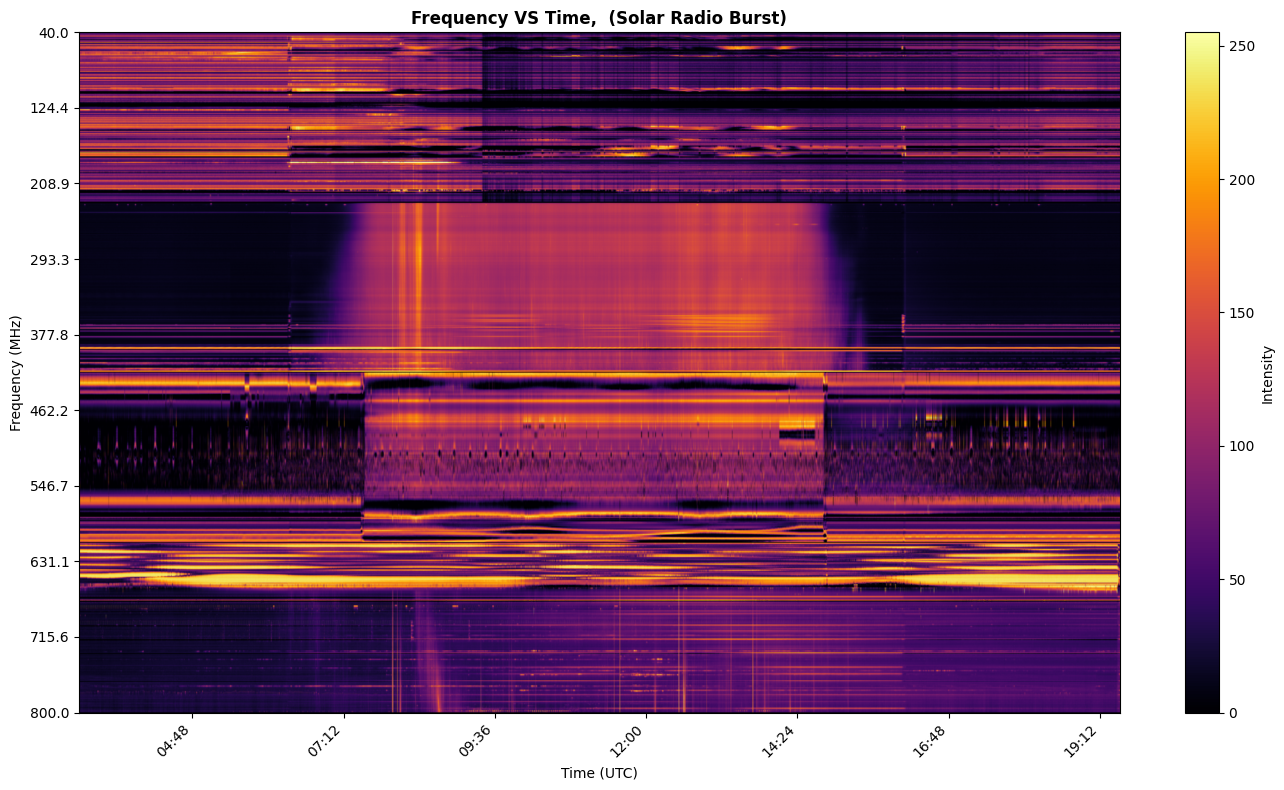

Display shows 1 out of every 10 time steps
Original full resolution would have been 594606 time points


In [6]:
print("Creating plot...")
t_plot = mdates.date2num(t_display)

plt.figure(figsize=(14, 8))
im = plt.imshow(
    dyspec_norm,
    aspect='auto',
    cmap='inferno',
    extent=[t_plot[0], t_plot[-1], Frequency[0], Frequency[-1]],
    interpolation='bilinear'
)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.xlabel('Time (UTC)')
plt.ylabel('Frequency (MHz)')
plt.title('Frequency VS Time,  (Solar Radio Burst)', fontweight="bold")
plt.colorbar(im, label='Intensity')
#plt.gca().invert_yaxis()  # Higher frequency at top
plt.yticks(np.linspace(Frequency[-1], Frequency[0], 10))
plt.tight_layout()
plt.show()

print(f"Display shows 1 out of every {display_factor} time steps")
print(f"Original full resolution would have been {a1} time points")